<a href="https://colab.research.google.com/github/regitaaft/iris-eda-ml/blob/main/ML_tugas_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval
Loan approval adalah data tentang pengajuan pinjaman (kredit) seseorang ke bank/lembaga keuangan dan apakah pengajuan itu disetujui atau ditolak.
### Tujuan
memprediksi apakah seseorang layak dapat pinjaman atau tidak

### import library

In [1]:
# Library dasar
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & split data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Boosting
from xgboost import XGBClassifier

pandas → baca & olah data

numpy → operasi numerik

sklearn → machine learning

RandomForest → bagging

XGBoost → boosting

MLPClassifier → neural network

### Load Dataset

In [3]:
df = pd.read_csv('loan_data_set.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Dataset yang digunakan dalam penelitian ini adalah Loan Approval Dataset yang berisi data karakteristik pemohon pinjaman.

Berdasarkan output di atas, dapat dilihat bahwa dataset terdiri dari beberapa variabel, antara lain:

1.  ApplicantIncome: pendapatan pemohon
2.   LoanAmount: jumlah pinjaman yang diajukan
3. Credit_History: riwayat kredit pemohon
4. Dependents: jumlah tanggungan yang dimiliki pemohon (misalnya anak atau keluarga yang dibiayai)
5. Education: tingkat pendidikan pemohon (Graduate = lulusan sarjana, Not Graduate = bukan sarjana)
6. Self_Employed: status pekerjaan pemohon (Yes = wiraswasta, No = bukan wiraswasta)
7. Loan_Status: status persetujuan pinjaman (target), dengan kategori Y (disetujui) dan N (ditolak)



### Cek Data

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


### Data Cleaning

In [24]:
df.fillna(df.mode().iloc[0], inplace=True)

### Encoding

In [34]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
  df[col] = le.fit_transform(df[col])
  df[['Gender','Education','Self_Employed']].head()

### Memisahkan fitur dan terget

In [20]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X = variabel input

y = Target

### Split Data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

80% training dan 20% test

### Scalling (NN)

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelling
### A. Random Forest (Bagging)

In [27]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7642276422764228


### XGBoost (Boosting)

In [28]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:27:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7642276422764228


### Neural Network

In [29]:
nn = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=500)
nn.fit(X_train_scaled, y_train)

y_pred_nn = nn.predict(X_test_scaled)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))

Neural Network Accuracy: 0.7642276422764228


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Evaluasi Model

In [30]:
print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

print("=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))

print("=== NEURAL NETWORK ===")
print(classification_report(y_test, y_pred_nn))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123

=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.75      0.49      0.59        43
           1       0.77      0.91      0.83        80

    accuracy                           0.76       123
   macro avg       0.76      0.70      0.71       123
weighted avg       0.76      0.76      0.75       123

=== NEURAL NETWORK ===
              precision    recall  f1-score   support

           0       0.79      0.44      0.57        43
           1       0.76      0.94      0.84        80

    accuracy                           0.76       123
   macro avg       0.77      0.69      0.70       123
weighted avg 

### Confusion Matrix

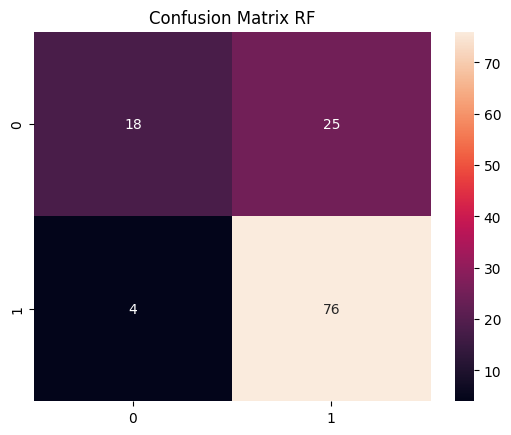

In [31]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix RF")
plt.show()

### Perbandingan Model

In [32]:
print("RF:", accuracy_score(y_test, y_pred_rf))
print("XGB:", accuracy_score(y_test, y_pred_xgb))
print("NN:", accuracy_score(y_test, y_pred_nn))

RF: 0.7642276422764228
XGB: 0.7642276422764228
NN: 0.7642276422764228
